# Flux: Monthly heatmaps of NEE (2005-2024) and FN2O (2012-2022)

**Author**: Lukas Hörtnagl (holukas@ethz.ch)

# Imports

In [1]:
import importlib.metadata
import warnings
from datetime import datetime
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import diive as dv
from diive.core.io.files import load_parquet
warnings.filterwarnings(action='ignore', category=FutureWarning)
warnings.filterwarnings(action='ignore', category=UserWarning)
version_diive = importlib.metadata.version("diive")
print(f"diive version: v{version_diive}")

diive version: v0.87.0


# Load data

In [2]:
SOURCEDIR = r"../80_FINALIZE"
FILENAME = r"81.1_FLUXES_M15_MGMT_L4.2_NEE_GPP_RECO_LE_H_FN2O_FCH4.parquet"
FILEPATH = Path(SOURCEDIR) / FILENAME
df = load_parquet(filepath=FILEPATH)
df

Loaded .parquet file ..\80_FINALIZE\81.1_FLUXES_M15_MGMT_L4.2_NEE_GPP_RECO_LE_H_FN2O_FCH4.parquet (6.237 seconds).
    --> Detected time resolution of <30 * Minutes> / 30min 


,.PREC_RAIN_TOT_GF1_0.5_1_MEAN3H-12,.PREC_RAIN_TOT_GF1_0.5_1_MEAN3H-18,.PREC_RAIN_TOT_GF1_0.5_1_MEAN3H-24,.PREC_RAIN_TOT_GF1_0.5_1_MEAN3H-6,.SWC_GF1_0.15_1_gfXG_MEAN3H-12,.SWC_GF1_0.15_1_gfXG_MEAN3H-18,.SWC_GF1_0.15_1_gfXG_MEAN3H-24,.SWC_GF1_0.15_1_gfXG_MEAN3H-6,.TS_GF1_0.04_1_gfXG_MEAN3H-12,.TS_GF1_0.04_1_gfXG_MEAN3H-18,.TS_GF1_0.04_1_gfXG_MEAN3H-24,.TS_GF1_0.04_1_gfXG_MEAN3H-6,.TS_GF1_0.15_1_gfXG_MEAN3H-12,.TS_GF1_0.15_1_gfXG_MEAN3H-18,.TS_GF1_0.15_1_gfXG_MEAN3H-24,...,GPP_NT_CUT_50_gfRF,RECO_DT_CUT_50_gfRF,GPP_DT_CUT_50_gfRF,RECO_DT_CUT_50_gfRF_SD,GPP_DT_CUT_50_gfRF_SD,G_GF1_0.03_1,G_GF1_0.03_2,G_GF1_0.05_1,G_GF1_0.05_2,G_GF4_0.02_1,G_GF5_0.02_1,LW_OUT_T1_2_1,NETRAD_T1_2_1,PPFD_OUT_T1_2_2,SW_OUT_T1_2_1
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2005-01-01 00:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.918553,0.093071,0.0,0.080016,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2005-01-01 00:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.917972,0.092682,0.0,0.079688,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2005-01-01 01:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.163001,0.093071,0.0,0.080016,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2005-01-01 01:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.190890,0.093071,0.0,0.080016,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2005-01-01 02:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.167042,0.092295,0.0,0.079361,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31 21:45:00,0.0,0.0,0.0,0.0,52.229004,52.226300,52.226689,52.216796,3.458828,3.150402,3.115260,3.660897,4.335667,4.347764,4.385967,...,-0.334996,1.091028,0.0,0.265808,0.0,NaN,NaN,-9.097370,-7.880106,NaN,NaN,311.167160,-5.883538,0.0,0.0
2024-12-31 22:15:00,0.0,0.0,0.0,0.0,52.227858,52.227986,52.224528,52.214211,3.522570,3.187638,3.103440,3.643396,4.338551,4.342880,4.379524,...,-0.310533,1.078751,0.0,0.264327,0.0,NaN,NaN,-9.561669,-8.172388,NaN,NaN,310.079817,-6.269816,0.0,0.0
2024-12-31 22:45:00,0.0,0.0,0.0,0.0,52.226640,52.229837,52.222456,52.209876,3.578745,3.230037,3.095339,3.624025,4.343767,4.339440,4.372636,...,-0.225651,1.079759,0.0,0.264447,0.0,NaN,NaN,-10.138718,-8.527732,NaN,NaN,309.604987,-6.934394,0.0,0.0


In [3]:
# [print(c) for c in df.columns if "FN2O" in c];

# NEE

In [4]:
nee = df['NEE_L3.1_L3.3_CUT_50_QCF_gfRF'].copy()
nee_var = "NEE"
nee_units = r"$\mathrm{\mu mol\ CO_{2}\ m^{-2}\ s^{-1}}$"
nee_zlabel = f"{nee_var} ({nee_units})"
nee

TIMESTAMP_MIDDLE
2005-01-01 00:15:00    0.911990
2005-01-01 00:45:00    0.910926
2005-01-01 01:15:00    1.667542
2005-01-01 01:45:00    1.639653
2005-01-01 02:15:00    1.660211
                         ...   
2024-12-31 21:45:00    1.160720
2024-12-31 22:15:00    1.131454
2024-12-31 22:45:00    1.046967
2024-12-31 23:15:00    1.372674
2024-12-31 23:45:00    1.126110
Freq: 30min, Name: NEE_L3.1_L3.3_CUT_50_QCF_gfRF, Length: 350640, dtype: float64

# FN2O

## Flux

In [5]:
fluxcol = 'FN2O_L3.1_L3.3_CUT_50_QCF_gfRF'
fn2o = df[[fluxcol]].copy()
fn2o['YEARMONTH'] = fn2o.index.year.astype(str) + "-" + fn2o.index.month.astype(str).str.zfill(2)
fn2o_var = r"$\mathrm{N_{2}O\ flux}$"
fn2o_units = r"$\mathrm{nmol\ N_{2}O\ m^{-2}\ s^{-1}}$"
fn2o_zlabel = f"{fn2o_var} ({fn2o_units})"
fn2o

,FN2O_L3.1_L3.3_CUT_50_QCF_gfRF,YEARMONTH
TIMESTAMP_MIDDLE,,
2005-01-01 00:15:00,NaN,2005-01
2005-01-01 00:45:00,NaN,2005-01
2005-01-01 01:15:00,NaN,2005-01
2005-01-01 01:45:00,NaN,2005-01
2005-01-01 02:15:00,NaN,2005-01
...,...,...
2024-12-31 21:45:00,NaN,2024-12
2024-12-31 22:15:00,NaN,2024-12
2024-12-31 22:45:00,NaN,2024-12


## Flag

,FLAG_FN2O_L3.1_L3.3_CUT_50_QCF_gfRF_ISFILLED
YEARMONTH,
2005-01,1488.0
2005-02,1344.0
2005-03,1488.0
2005-04,1440.0
2005-05,1488.0
...,...
2024-08,1488.0
2024-09,1440.0
2024-10,1488.0


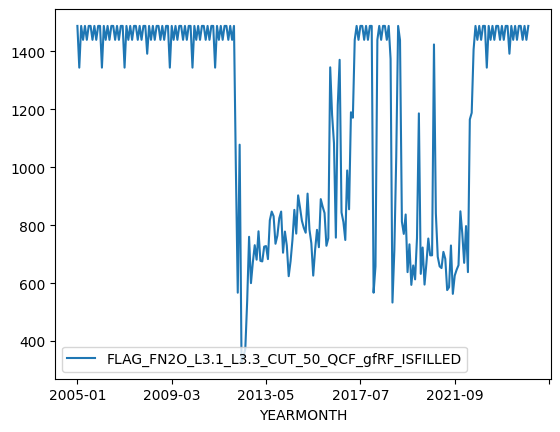

In [6]:
flagcol = 'FLAG_FN2O_L3.1_L3.3_CUT_50_QCF_gfRF_ISFILLED'
flag_fn2o = df[flagcol].copy()
flag_fn2o = flag_fn2o.fillna(1)
flag_fn2o.loc[flag_fn2o > 1] = 1  # Some locations have flag values > 1 due to MDS gap-filling
flag_fn2o = pd.DataFrame(flag_fn2o)
flag_fn2o['YEARMONTH'] = flag_fn2o.index.year.astype(str) + "-" + flag_fn2o.index.month.astype(str).str.zfill(2)
flag_fn2o = flag_fn2o.groupby('YEARMONTH').sum()
flag_fn2o.plot(x_compat=True);
flag_fn2o

## Checking number of available non-gap-filled records
If keeping data from months using 15% threshold (i.e. 15% measured and 85% gap-filled) then the stats are:  
mean data availability (not gap-filled) in shown months = 48.4%  
data coverage between 17.5% (June 2022) and 77.2% (April 2012)

In [65]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)

flagcol = 'FLAG_FN2O_L3.1_L3.3_CUT_50_QCF_gfRF_ISFILLED'
f = df[flagcol].copy()
f = f.fillna(1)
f = pd.DataFrame(f)
f['YEARMONTH'] = f.index.year.astype(str) + "-" + f.index.month.astype(str).str.zfill(2)
f = f.groupby(f['YEARMONTH']).count()
max_available = f.copy()
# display(max_available)

flagcol = 'FLAG_FN2O_L3.1_L3.3_CUT_50_QCF_gfRF_ISFILLED'
f = df[flagcol].copy()
f = f.fillna(1)
f = f.loc[f == 0].copy()
f = pd.DataFrame(f)
f['YEARMONTH'] = f.index.year.astype(str) + "-" + f.index.month.astype(str).str.zfill(2)
f = f.groupby(f['YEARMONTH']).count()
# f.plot(x_compat=True);
available = f.copy()
# display(available)

_df = pd.DataFrame()
_df['max_available'] = max_available
_df['available'] = available
_df['available'] = _df['available'].fillna(0)
_df['perc_available'] = _df['available'].div(_df['max_available'])
_df['perc_available'] = _df['perc_available'].multiply(100)
keeplocs = _df['perc_available'] > 15
_df = _df[keeplocs].copy()
_df.describe()
display(_df)

# data = {'available': available, 'max_available': max_available}
# _df = pd.DataFrame(data, index=available.index)
# _df

# perc_available = available.div(max_available)
# perc_available.describe()



,max_available,available,perc_available
YEARMONTH,,,
2012-01,1488,493.0,33.131720
2012-02,1392,825.0,59.267241
2012-03,1488,410.0,27.553763
2012-04,1440,1112.0,77.222222
2012-05,1488,1143.0,76.814516
2012-06,1440,1067.0,74.097222
2012-07,1488,949.0,63.776882
2012-08,1488,728.0,48.924731
2012-09,1440,840.0,58.333333


## Merge gap-fill counts

In [9]:
# Rename the flag column in _df for clarity after merging
flag_fn2o = flag_fn2o.rename(columns={'FLAG_FN2O_L3.1_L3.3_CUT_50_QCF_gfRF_ISFILLED': 'GapFillCount'})

# Merge fn2o with flag_fn2o to bring the monthly gap-fill counts into fn2o's DataFrame
# We'll merge on 'YEARMONTH'
fn2o_merged = pd.merge(fn2o, flag_fn2o, on='YEARMONTH', how='left')

# Restore the original TIMESTAMP_MIDDLE as index and drop the helper YEARMONTH column
fn2o_merged = fn2o_merged.set_index(fn2o.index)
fn2o_merged = fn2o_merged.drop(columns=['YEARMONTH'])

# Filter the flux data based on the 'GapFillCount'
# Keep flux data only where 'GapFillCount' is less than 1000
fn2o_filtered = fn2o_merged[fn2o_merged['GapFillCount'] < 1400]
fn2o_final = fn2o_filtered[fluxcol] # Use fn2o.name to get the original column name

fn2o_final = fn2o_final.reindex(fn2o.index)
fn2o_final

TIMESTAMP_MIDDLE
2005-01-01 00:15:00   NaN
2005-01-01 00:45:00   NaN
2005-01-01 01:15:00   NaN
2005-01-01 01:45:00   NaN
2005-01-01 02:15:00   NaN
                       ..
2024-12-31 21:45:00   NaN
2024-12-31 22:15:00   NaN
2024-12-31 22:45:00   NaN
2024-12-31 23:15:00   NaN
2024-12-31 23:45:00   NaN
Freq: 30min, Name: FN2O_L3.1_L3.3_CUT_50_QCF_gfRF, Length: 350640, dtype: float64

# Heatmap

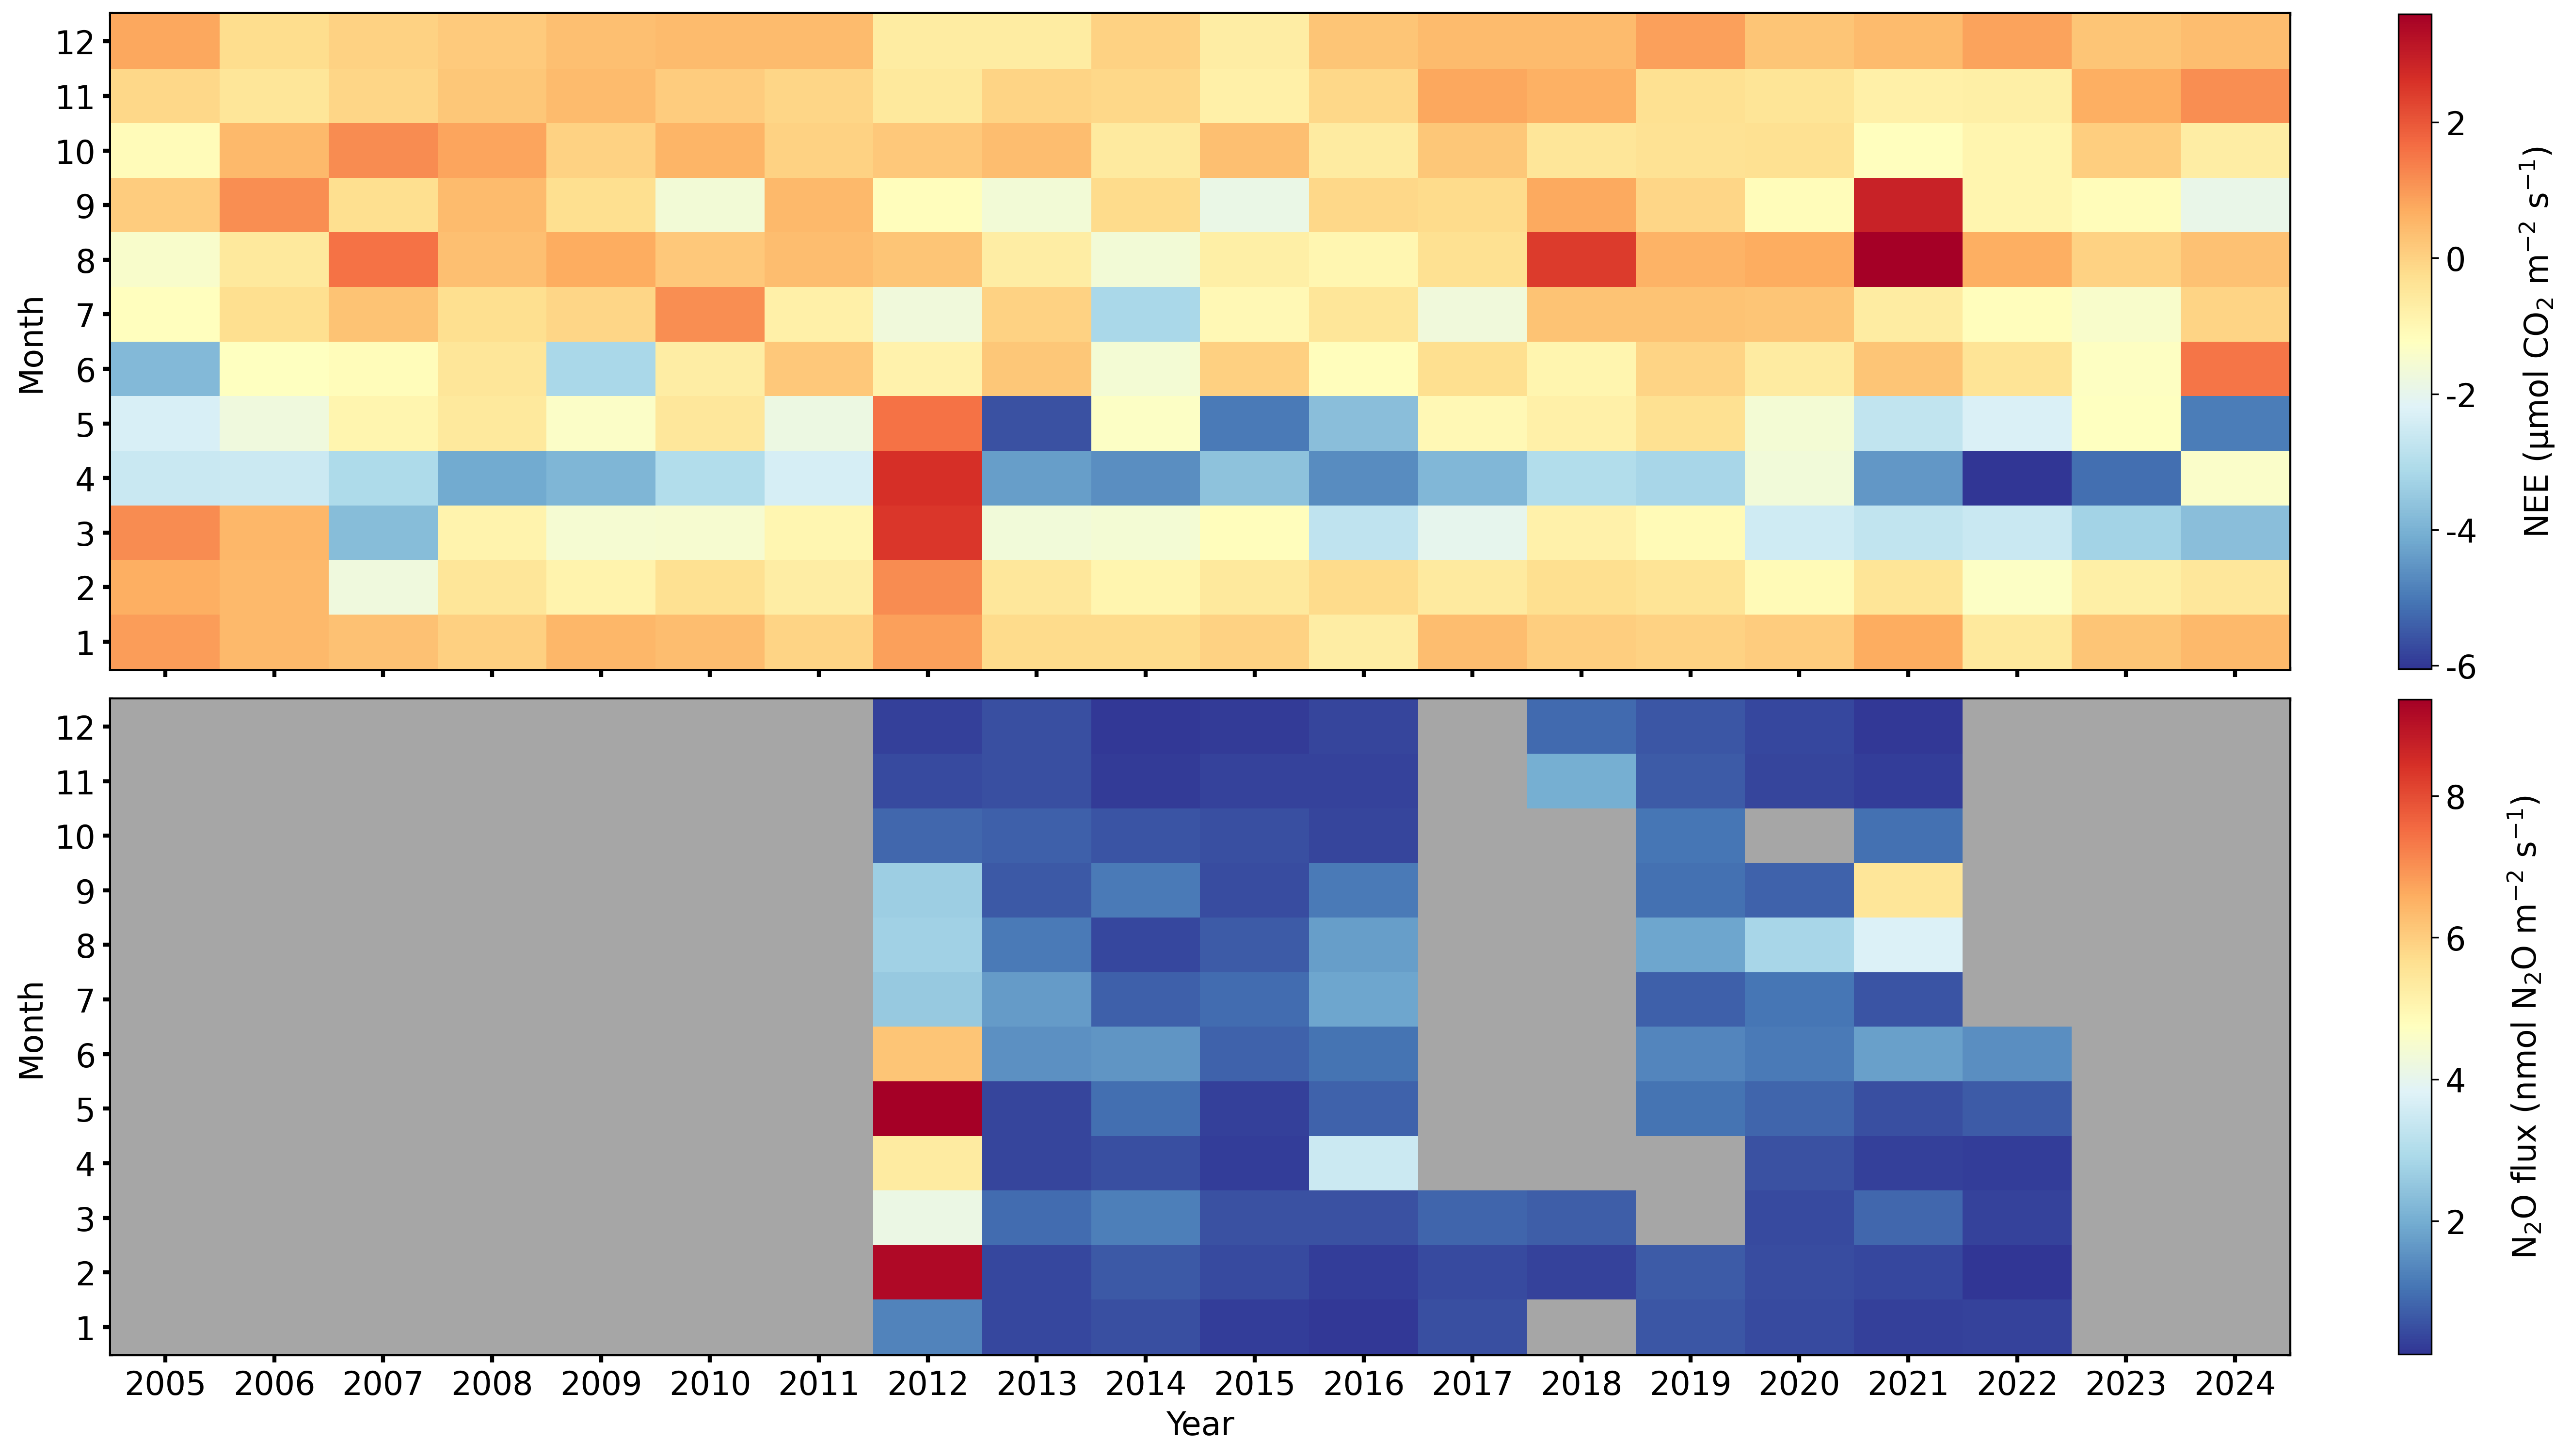

In [10]:
fig = plt.figure(facecolor='white', figsize=(17.6, 9.9), layout="constrained", dpi=300)
gs = gridspec.GridSpec(2, 1, figure=fig)  # rows, cols
# gs.update(wspace=0.5, hspace=0.3, left=0.03, right=0.97, top=0.97, bottom=0.03)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[1, 0])
settings = dict(ax_orientation='horizontal', cb_digits_after_comma=0, show_values=False)
dv.heatmapyearmonth(ax=ax1, series=nee, agg='mean', zlabel=nee_zlabel, **settings).plot()
dv.heatmapyearmonth(ax=ax2, series=fn2o_final, agg='mean', zlabel=fn2o_zlabel, color_bad='#a6a6a6', **settings).plot()
ax1.set_xlabel("")
ax1.set_xticklabels("")
ax1.set_title("")
ax2.set_title("")
fig.show()

# Save figure to file

In [10]:
fig.savefig('FLUX_NEE_FN2O_MonthlyHeatmaps_Figure1.png', dpi=300)

# End of notebook

In [11]:
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Finished. {dt_string}")

Finished. 2025-07-01 16:43:59
